In [30]:
import time

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

In [56]:
TRAIN_SIZE = 10000
VAL_SIZE = 2000
ARCHS = [
    [512,400,512],
    [256, 128, 128, 256],
    [512, 256, 128, 256, 512],
    [512, 256, 128, 64, 128, 256, 512],
    [384, 256, 128, 64, 128, 256, 384],
]
EPOCHS = 5
BATCH_SIZE = 256
LR = 1e-2
SEED = 42

In [57]:
def images_to_matrix(images) -> np.ndarray:
    return np.stack(
        [np.array(img, dtype=np.float32).reshape(-1) / 255.0 for img in images],
        axis=0,
    )


def load_fashion_mnist(
    train_size: int,
    val_size: int,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    ds = load_dataset("fashion_mnist")
    rng = np.random.default_rng(seed)

    train_idx = rng.choice(len(ds["train"]), size=train_size, replace=False)
    val_idx = rng.choice(len(ds["test"]), size=val_size, replace=False)

    train_split = ds["train"].select(train_idx)
    val_split = ds["test"].select(val_idx)

    X_train = images_to_matrix(train_split["image"])
    X_val = images_to_matrix(val_split["image"])

    return X_train, X_val


X_train, X_val = load_fashion_mnist(TRAIN_SIZE, VAL_SIZE, SEED)
print("Train/val shapes:", X_train.shape, X_val.shape)

Train/val shapes: (10000, 784) (2000, 784)


In [58]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, x)


def init_params(layer_sizes: list[int], seed: int) -> dict[str, np.ndarray]:
    rng = np.random.default_rng(seed)
    params = {}
    for i in range(len(layer_sizes) - 1):
        in_dim = layer_sizes[i]
        out_dim = layer_sizes[i + 1]
        params[f"W{i}"] = rng.normal(0.0, 0.02, size=(in_dim, out_dim))
        params[f"b{i}"] = np.zeros(out_dim)
    return params


def forward(X: np.ndarray, params: dict[str, np.ndarray]) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    A = X
    cache = {"A0": X}
    num_layers = len(params) // 2

    for i in range(num_layers):
        Z = A @ params[f"W{i}"] + params[f"b{i}"]
        if i == num_layers - 1:
            A = sigmoid(Z)
        else:
            A = relu(Z)
        cache[f"Z{i+1}"] = Z
        cache[f"A{i+1}"] = A

    return A, cache


def mse_loss(Y: np.ndarray, X: np.ndarray) -> float:
    return float(np.mean((Y - X) ** 2))


def backward(cache: dict[str, np.ndarray], params: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    num_layers = len(params) // 2
    X = cache["A0"]
    Y = cache[f"A{num_layers}"]
    n = X.shape[0]

    dA = (2.0 / n) * (Y - X)
    grads: dict[str, np.ndarray] = {}

    for i in reversed(range(num_layers)):
        Z = cache[f"Z{i+1}"]
        A_prev = cache[f"A{i}"]
        if i == num_layers - 1:
            dZ = dA * (Y * (1.0 - Y))
        else:
            dZ = dA * (Z > 0.0)

        grads[f"W{i}"] = A_prev.T @ dZ
        grads[f"b{i}"] = dZ.sum(axis=0)

        if i > 0:
            dA = dZ @ params[f"W{i}"].T

    return grads


def sgd_step(params: dict[str, np.ndarray], grads: dict[str, np.ndarray], lr: float) -> None:
    for key in params:
        params[key] -= lr * grads[key]

In [59]:
def pixel_accuracy(Y: np.ndarray, X: np.ndarray) -> float:
    Yb = (Y >= 0.5).astype(np.int8)
    Xb = (X >= 0.5).astype(np.int8)
    return float(np.mean(Yb == Xb))


def evaluate(X: np.ndarray, params: dict[str, np.ndarray]) -> tuple[float, float]:
    Y, _ = forward(X, params)
    return mse_loss(Y, X), pixel_accuracy(Y, X)


def train_autoencoder(
    X_train: np.ndarray,
    X_val: np.ndarray,
    hidden_layers: list[int],
    epochs: int,
    batch_size: int,
    lr: float,
    seed: int,
) -> tuple[dict[str, np.ndarray], dict[str, list[float]]]:
    layer_sizes = [X_train.shape[1]] + hidden_layers + [X_train.shape[1]]
    params = init_params(layer_sizes, seed)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    rng = np.random.default_rng(seed)

    for _ in range(epochs):
        idx = rng.permutation(len(X_train))
        X_shuf = X_train[idx]

        for start in range(0, len(X_shuf), batch_size):
            Xb = X_shuf[start : start + batch_size]
            _, cache = forward(Xb, params)
            grads = backward(cache, params)
            sgd_step(params, grads, lr)

        tr_loss, tr_acc = evaluate(X_train, params)
        va_loss, va_acc = evaluate(X_val, params)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

    return params, history

In [60]:
def arch_label(arch: list[int]) -> str:
    return "-".join(str(x) for x in arch)


runs = {}
labels = [arch_label(arch) for arch in ARCHS]

for arch, label in zip(ARCHS, labels):
    start = time.perf_counter()
    params, history = train_autoencoder(
        X_train,
        X_val,
        hidden_layers=arch,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        seed=SEED,
    )
    duration = time.perf_counter() - start
    runs[label] = {"params": params, "history": history, "time": duration, "arch": arch}
    print(
        f"arch={label} | time={duration:.1f}s | "
        f"train_acc={history['train_acc'][-1]:.3f} | val_acc={history['val_acc'][-1]:.3f}"
    )

arch=512-400-512 | time=11.1s | train_acc=0.826 | val_acc=0.827
arch=256-128-128-256 | time=6.3s | train_acc=0.727 | val_acc=0.724
arch=512-256-128-256-512 | time=10.4s | train_acc=0.723 | val_acc=0.720
arch=512-256-128-64-128-256-512 | time=10.5s | train_acc=0.729 | val_acc=0.727
arch=384-256-128-64-128-256-384 | time=8.7s | train_acc=0.729 | val_acc=0.727


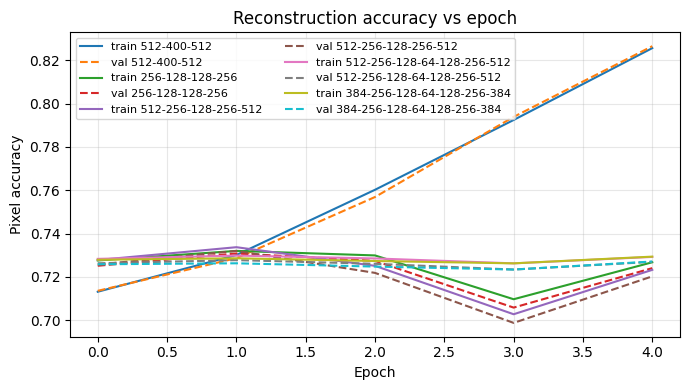

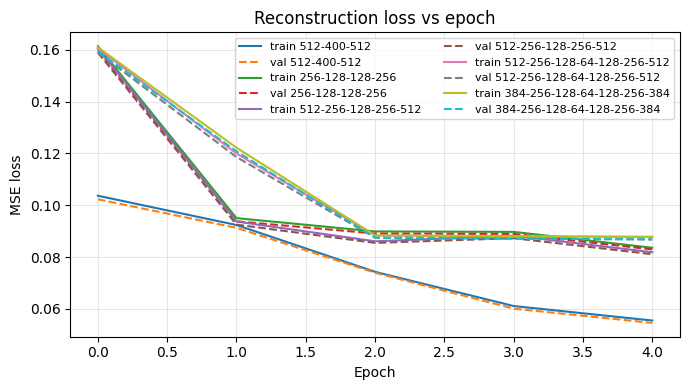

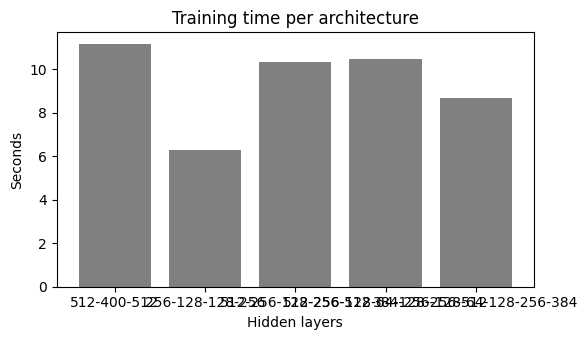

In [61]:
plt.figure(figsize=(7, 4))
for label in labels:
    hist = runs[label]["history"]
    plt.plot(hist["train_acc"], label=f"train {label}")
    plt.plot(hist["val_acc"], linestyle="--", label=f"val {label}")

plt.title("Reconstruction accuracy vs epoch")
plt.xlabel("Epoch")
plt.ylabel("Pixel accuracy")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
for label in labels:
    hist = runs[label]["history"]
    plt.plot(hist["train_loss"], label=f"train {label}")
    plt.plot(hist["val_loss"], linestyle="--", label=f"val {label}")

plt.title("Reconstruction loss vs epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
plt.bar(labels, [runs[label]["time"] for label in labels], color="gray")
plt.title("Training time per architecture")
plt.xlabel("Hidden layers")
plt.ylabel("Seconds")
plt.tight_layout()
plt.show()

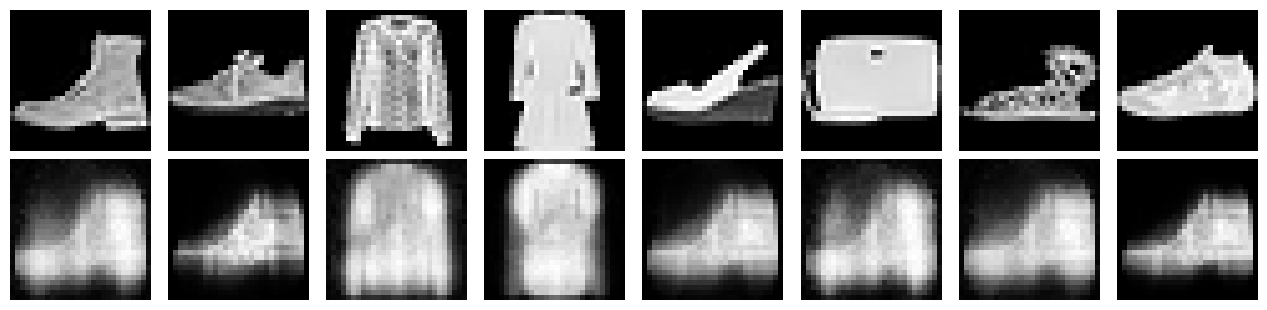

In [62]:
def show_reconstructions(X: np.ndarray, params: dict[str, np.ndarray], n: int = 8) -> None:
    Y, _ = forward(X[:n], params)
    fig, axes = plt.subplots(2, n, figsize=(1.6 * n, 3.2))
    for i in range(n):
        axes[0, i].imshow(X[i].reshape(28, 28), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(Y[i].reshape(28, 28), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=10)
    axes[1, 0].set_ylabel("Recon", fontsize=10)
    plt.tight_layout()
    plt.show()


best_label = max(labels, key=lambda lab: runs[lab]["history"]["val_acc"][-1])
show_reconstructions(X_val, runs[best_label]["params"], n=8)

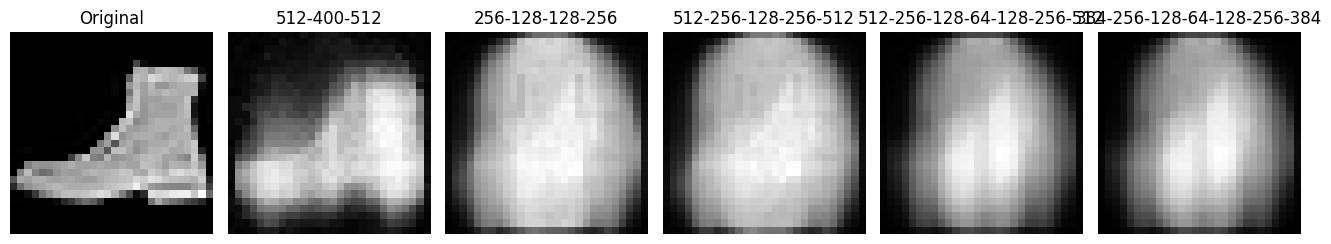

In [63]:
sample = X_val[0]

fig, axes = plt.subplots(1, len(labels) + 1, figsize=(2.2 * (len(labels) + 1), 2.5))
axes[0].imshow(sample.reshape(28, 28), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i, label in enumerate(labels, start=1):
    recon, _ = forward(sample[None, :], runs[label]["params"])
    axes[i].imshow(recon[0].reshape(28, 28), cmap="gray")
    axes[i].set_title(label)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [64]:
summary = {
    label: {
        "arch": runs[label]["arch"],
        "time_sec": round(runs[label]["time"], 2),
        "train_acc": round(runs[label]["history"]["train_acc"][-1], 4),
        "val_acc": round(runs[label]["history"]["val_acc"][-1], 4),
    }
    for label in labels
}

print(
    "Diagnostic: numpy autoencoder | "
    f"archs={ARCHS} | epochs={EPOCHS} | batch={BATCH_SIZE} | lr={LR} | "
    f"train_size={TRAIN_SIZE} | val_size={VAL_SIZE} | results={summary}"
)

Diagnostic: numpy autoencoder | archs=[[512, 400, 512], [256, 128, 128, 256], [512, 256, 128, 256, 512], [512, 256, 128, 64, 128, 256, 512], [384, 256, 128, 64, 128, 256, 384]] | epochs=5 | batch=256 | lr=0.01 | train_size=10000 | val_size=2000 | results={'512-400-512': {'arch': [512, 400, 512], 'time_sec': 11.14, 'train_acc': 0.8257, 'val_acc': 0.8266}, '256-128-128-256': {'arch': [256, 128, 128, 256], 'time_sec': 6.29, 'train_acc': 0.7267, 'val_acc': 0.724}, '512-256-128-256-512': {'arch': [512, 256, 128, 256, 512], 'time_sec': 10.35, 'train_acc': 0.7232, 'val_acc': 0.7202}, '512-256-128-64-128-256-512': {'arch': [512, 256, 128, 64, 128, 256, 512], 'time_sec': 10.47, 'train_acc': 0.7292, 'val_acc': 0.7269}, '384-256-128-64-128-256-384': {'arch': [384, 256, 128, 64, 128, 256, 384], 'time_sec': 8.66, 'train_acc': 0.7293, 'val_acc': 0.7271}}
